In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your heroes
with open(r"C:\Divyansh\HeroClash\backend\app\data\heroes.json") as f:
    heroes = json.load(f)

print(f"Total heroes loaded: {len(heroes)}")

Total heroes loaded: 731


In [2]:
rows = []

for hero in heroes:
    stats = hero["powerstats"]
    bio = hero["biography"]
    appearance = hero["appearance"]
    
    # Try to parse stats — some heroes have "null" values
    try:
        intelligence = int(stats["intelligence"])
        strength = int(stats["strength"])
        speed = int(stats["speed"])
        durability = int(stats["durability"])
        power = int(stats["power"])
        combat = int(stats["combat"])
        valid_stats = True
    except (ValueError, TypeError):
        intelligence = strength = speed = durability = power = combat = None
        valid_stats = False
    
    rows.append({
        "id": hero["id"],
        "name": hero["name"],
        "publisher": bio["publisher"],
        "alignment": bio["alignment"],
        "gender": appearance["gender"],
        "race": appearance["race"],
        "intelligence": intelligence,
        "strength": strength,
        "speed": speed,
        "durability": durability,
        "power": power,
        "combat": combat,
        "valid_stats": valid_stats
    })

df = pd.DataFrame(rows)

print(f"Total heroes: {len(df)}")
print(f"Heroes with valid stats: {df['valid_stats'].sum()}")
print(f"Heroes with null stats: {(~df['valid_stats']).sum()}")
print()
print(df.head())

Total heroes: 731
Heroes with valid stats: 566
Heroes with null stats: 165

  id         name          publisher alignment gender               race  \
0  1       A-Bomb      Marvel Comics      good   Male              Human   
1  2   Abe Sapien  Dark Horse Comics      good   Male      Icthyo Sapien   
2  3     Abin Sur          DC Comics      good   Male            Ungaran   
3  4  Abomination      Marvel Comics       bad   Male  Human / Radiation   
4  5      Abraxas      Marvel Comics       bad   Male      Cosmic Entity   

   intelligence  strength  speed  durability  power  combat  valid_stats  
0          38.0     100.0   17.0        80.0   24.0    64.0         True  
1          88.0      28.0   35.0        65.0  100.0    85.0         True  
2          50.0      90.0   53.0        64.0   99.0    65.0         True  
3          63.0      80.0   53.0        90.0   62.0    95.0         True  
4          88.0      63.0   83.0       100.0  100.0    55.0         True  


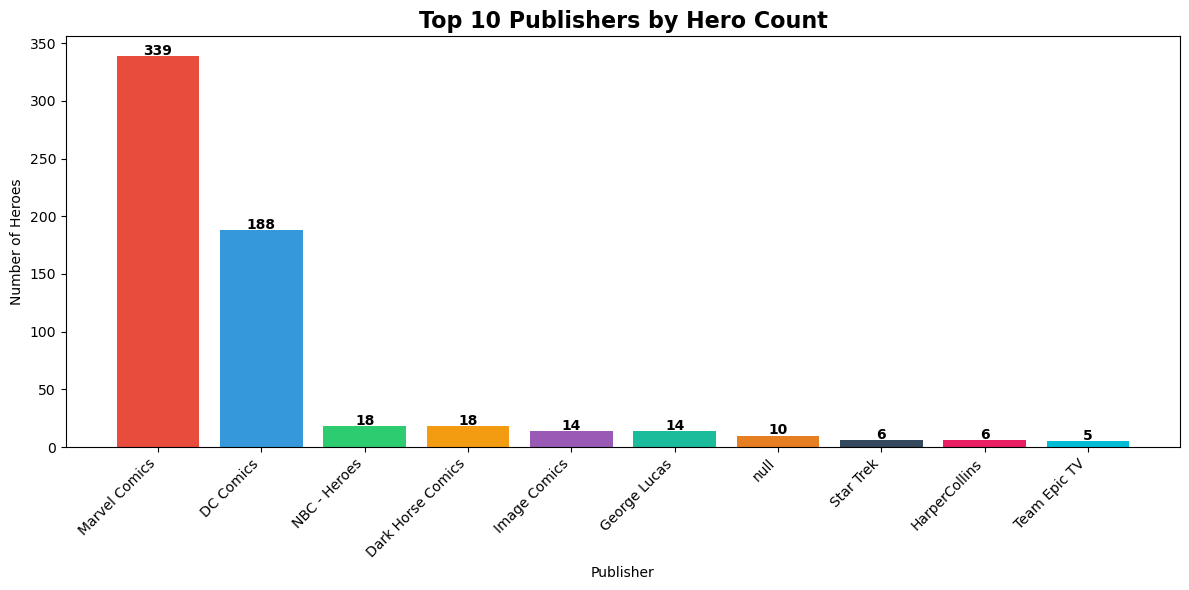

publisher
Marvel Comics        339
DC Comics            188
NBC - Heroes          18
Dark Horse Comics     18
Image Comics          14
George Lucas          14
null                  10
Star Trek              6
HarperCollins          6
Team Epic TV           5
Name: count, dtype: int64


In [3]:
publisher_counts = df['publisher'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(publisher_counts.index, publisher_counts.values, color=['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22', '#34495E', '#E91E63', '#00BCD4'])
plt.title('Top 10 Publishers by Hero Count', fontsize=16, fontweight='bold')
plt.xlabel('Publisher')
plt.ylabel('Number of Heroes')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, publisher_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(publisher_counts)

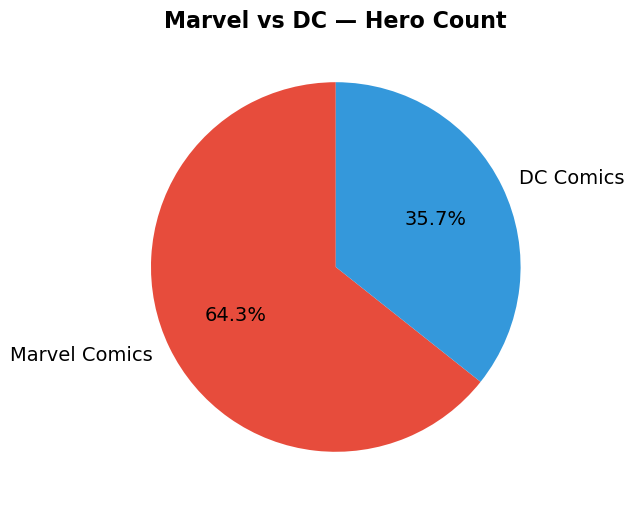

publisher
Marvel Comics    339
DC Comics        188
Name: count, dtype: int64


In [4]:
marvel_dc = df[df['publisher'].isin(['Marvel Comics', 'DC Comics'])]

counts = marvel_dc['publisher'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', 
        colors=['#E74C3C', '#3498DB'], startangle=90,
        textprops={'fontsize': 14})
plt.title('Marvel vs DC — Hero Count', fontsize=16, fontweight='bold')
plt.show()

print(counts)

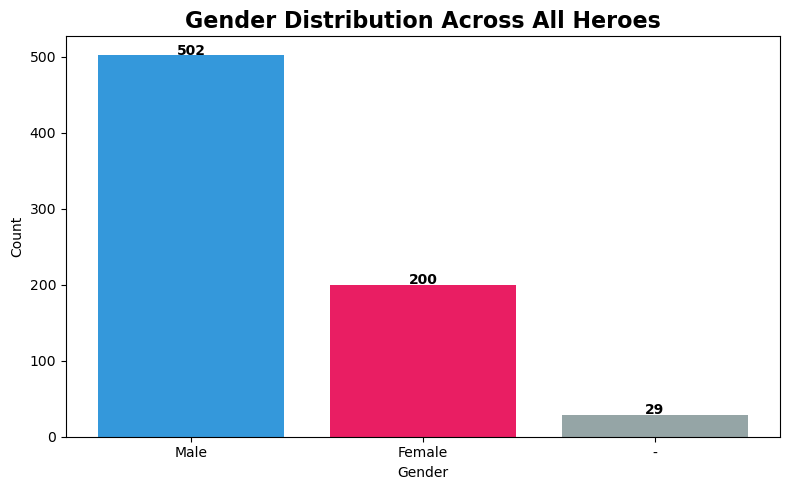

gender
Male      502
Female    200
-          29
Name: count, dtype: int64


In [5]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(gender_counts.index, gender_counts.values, 
               color=['#3498DB', '#E91E63', '#95A5A6'])
plt.title('Gender Distribution Across All Heroes', fontsize=16, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')

for bar, val in zip(bars, gender_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(gender_counts)

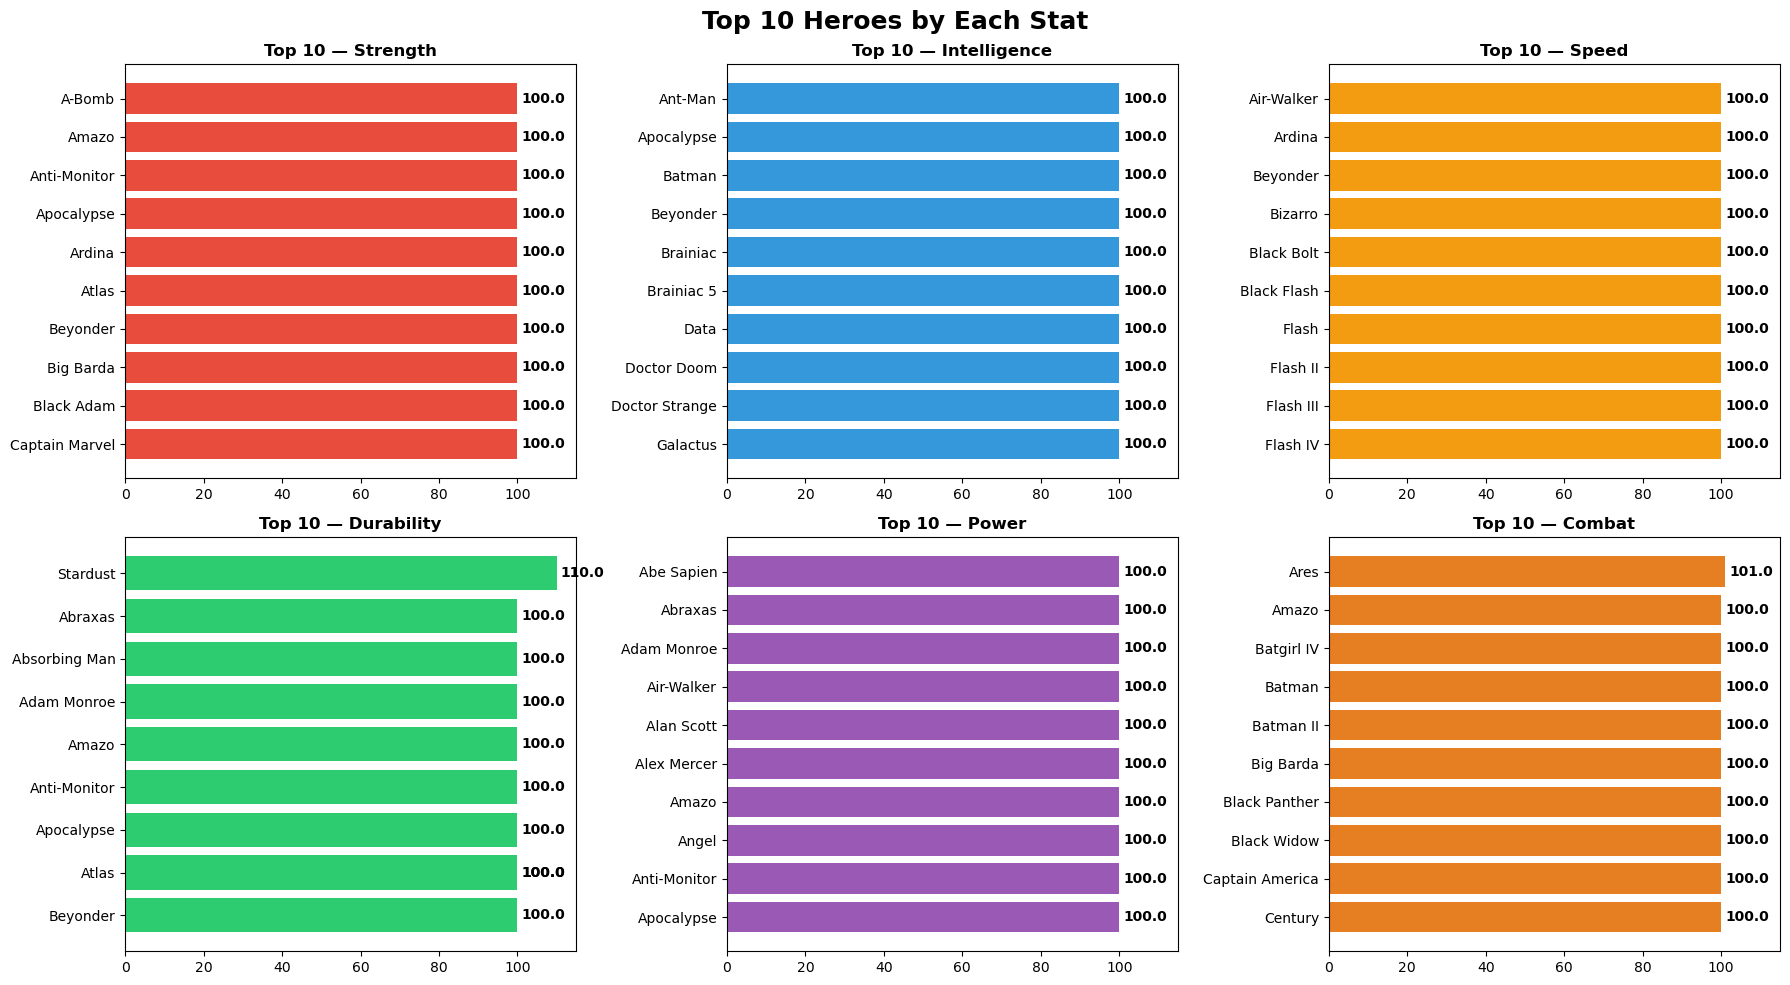

In [6]:
valid = df[df['valid_stats'] == True].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top 10 Heroes by Each Stat', fontsize=18, fontweight='bold')

stats = ['strength', 'intelligence', 'speed', 'durability', 'power', 'combat']
colors = ['#E74C3C', '#3498DB', '#F39C12', '#2ECC71', '#9B59B6', '#E67E22']

for ax, stat, color in zip(axes.flatten(), stats, colors):
    top10 = valid.nlargest(10, stat)[['name', stat]]
    bars = ax.barh(top10['name'], top10[stat], color=color)
    ax.set_title(f'Top 10 — {stat.capitalize()}', fontweight='bold')
    ax.set_xlim(0, 115)
    for bar, val in zip(bars, top10[stat]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                str(val), va='center', fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

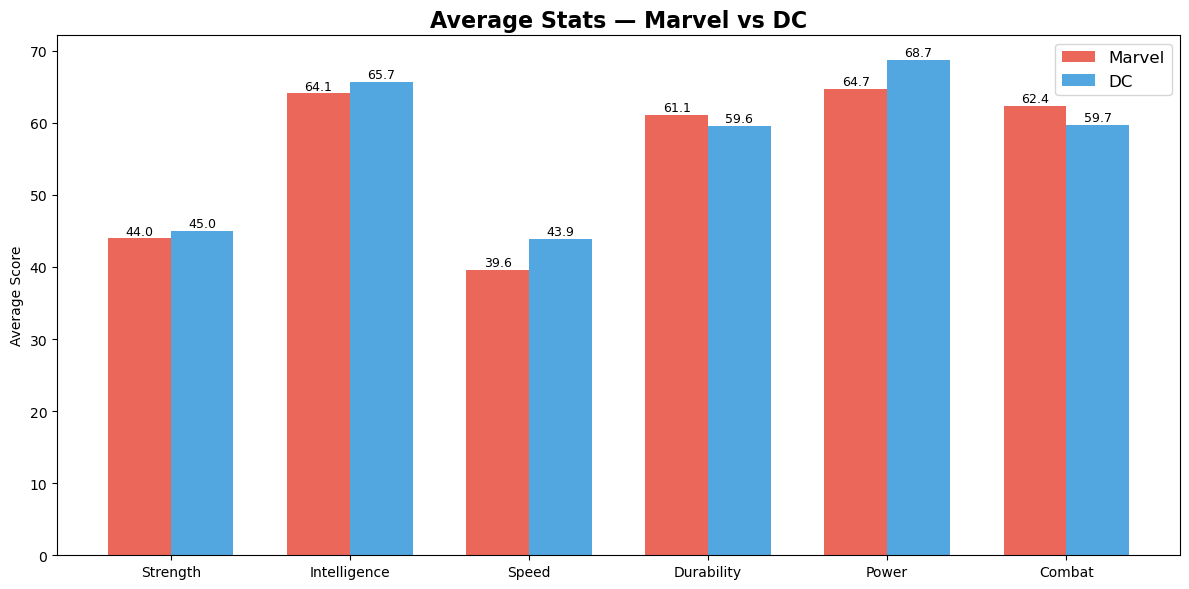

               strength  intelligence  speed  durability  power  combat
publisher                                                              
DC Comics          45.0          65.7   43.9        59.6   68.7    59.7
Marvel Comics      44.0          64.1   39.6        61.1   64.7    62.4


In [7]:
marvel_dc_valid = valid[valid['publisher'].isin(['Marvel Comics', 'DC Comics'])]

avg_stats = marvel_dc_valid.groupby('publisher')[stats].mean().round(1)

x = np.arange(len(stats))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, avg_stats.loc['Marvel Comics'], width, 
               label='Marvel', color='#E74C3C', alpha=0.85)
bars2 = ax.bar(x + width/2, avg_stats.loc['DC Comics'], width, 
               label='DC', color='#3498DB', alpha=0.85)

ax.set_title('Average Stats — Marvel vs DC', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in stats])
ax.legend(fontsize=12)
ax.set_ylabel('Average Score')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(avg_stats)

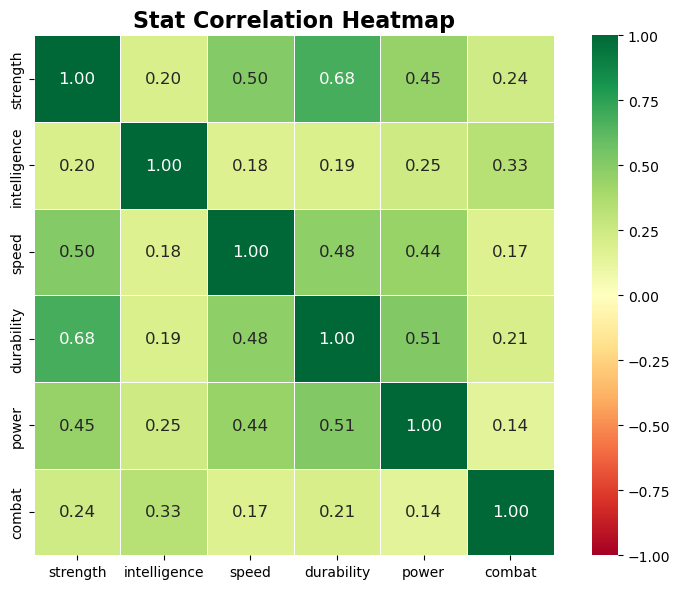

In [8]:
plt.figure(figsize=(8, 6))
corr = valid[stats].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True,
            linewidths=0.5, annot_kws={'size': 12})

plt.title('Stat Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

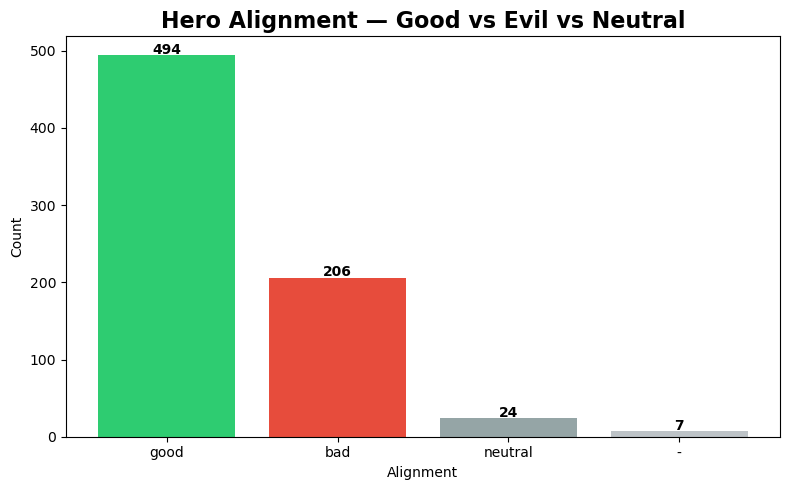

alignment
good       494
bad        206
neutral     24
-            7
Name: count, dtype: int64


In [9]:
alignment_counts = df['alignment'].value_counts()

plt.figure(figsize=(8, 5))
colors = {'good': '#2ECC71', 'bad': '#E74C3C', 'neutral': '#95A5A6', '-': '#BDC3C7'}
bar_colors = [colors.get(a, '#BDC3C7') for a in alignment_counts.index]

bars = plt.bar(alignment_counts.index, alignment_counts.values, color=bar_colors)
plt.title('Hero Alignment — Good vs Evil vs Neutral', fontsize=16, fontweight='bold')
plt.xlabel('Alignment')
plt.ylabel('Count')

for bar, val in zip(bars, alignment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(alignment_counts)

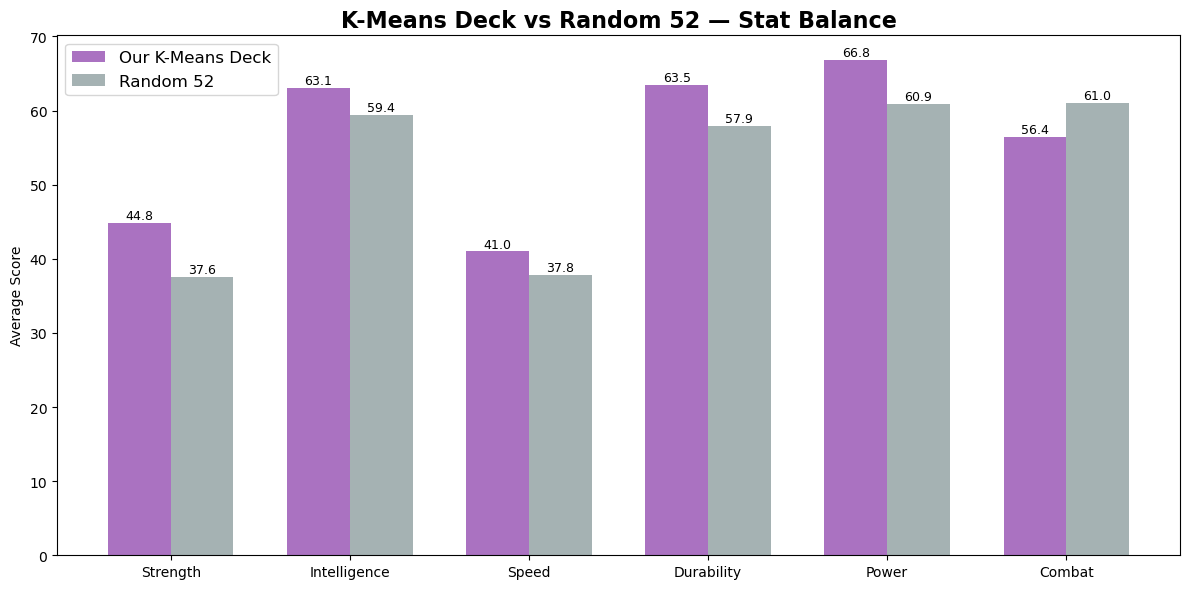

              K-Means Deck  Random 52
strength              44.8       37.6
intelligence          63.1       59.4
speed                 41.0       37.8
durability            63.5       57.9
power                 66.8       60.9
combat                56.4       61.0


In [12]:
import random

# Define stats as a list explicitly
stats_list = ['strength', 'intelligence', 'speed', 'durability', 'power', 'combat']

# Load our K-Means deck
with open(r"C:\Divyansh\HeroClash\backend\app\data\deck.json") as f:
    deck = json.load(f)

# Parse deck stats
deck_stats = []
for hero in deck:
    s = hero["powerstats"]
    try:
        deck_stats.append({
            "name": hero["name"],
            "strength": int(s["strength"]),
            "intelligence": int(s["intelligence"]),
            "speed": int(s["speed"]),
            "durability": int(s["durability"]),
            "power": int(s["power"]),
            "combat": int(s["combat"])
        })
    except:
        pass

deck_df = pd.DataFrame(deck_stats)

# Random 52 from valid heroes for comparison
random_52 = valid.sample(52, random_state=99)

# Compare average stats
deck_avg = deck_df[stats_list].mean().round(1)
random_avg = random_52[stats_list].mean().round(1)

comparison = pd.DataFrame({
    'K-Means Deck': deck_avg,
    'Random 52': random_avg
})

x = np.arange(len(stats_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, comparison['K-Means Deck'], width,
               label='Our K-Means Deck', color='#9B59B6', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison['Random 52'], width,
               label='Random 52', color='#95A5A6', alpha=0.85)

ax.set_title('K-Means Deck vs Random 52 — Stat Balance', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in stats_list])
ax.legend(fontsize=12)
ax.set_ylabel('Average Score')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(comparison)

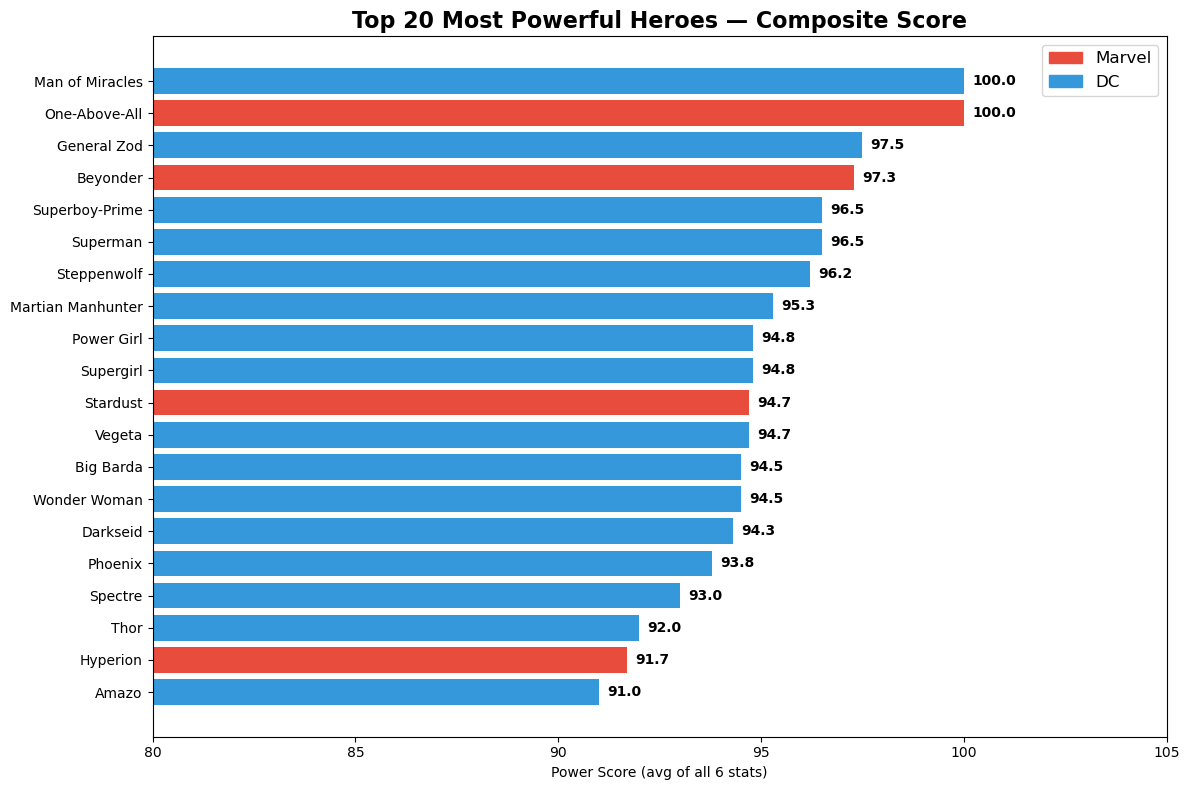

                  name                   publisher  power_score
425    Man of Miracles                Image Comics        100.0
502      One-Above-All               Marvel Comics        100.0
277        General Zod                   DC Comics         97.5
79            Beyonder               Marvel Comics         97.3
641     Superboy-Prime                   DC Comics         96.5
643           Superman  Superman Prime One-Million         96.5
636        Steppenwolf                   DC Comics         96.2
431  Martian Manhunter                   DC Comics         95.3
523         Power Girl                   DC Comics         94.8
642          Supergirl                   DC Comics         94.8
630           Stardust               Marvel Comics         94.7
685             Vegeta                    Shueisha         94.7
80           Big Barda                   DC Comics         94.5
719       Wonder Woman                   DC Comics         94.5
203           Darkseid                  

In [13]:
# Create composite power score = average of all 6 stats
valid['power_score'] = valid[stats_list].mean(axis=1).round(1)

top20 = valid.nlargest(20, 'power_score')[['name', 'publisher', 'power_score']]

plt.figure(figsize=(12, 8))
colors = ['#E74C3C' if 'Marvel' in p else '#3498DB' for p in top20['publisher']]
bars = plt.barh(top20['name'], top20['power_score'], color=colors)

plt.title('Top 20 Most Powerful Heroes — Composite Score', fontsize=16, fontweight='bold')
plt.xlabel('Power Score (avg of all 6 stats)')
plt.xlim(80, 105)

for bar, val in zip(bars, top20['power_score']):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#E74C3C', label='Marvel'), Patch(color='#3498DB', label='DC')]
plt.legend(handles=legend, fontsize=12)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top20.to_string())

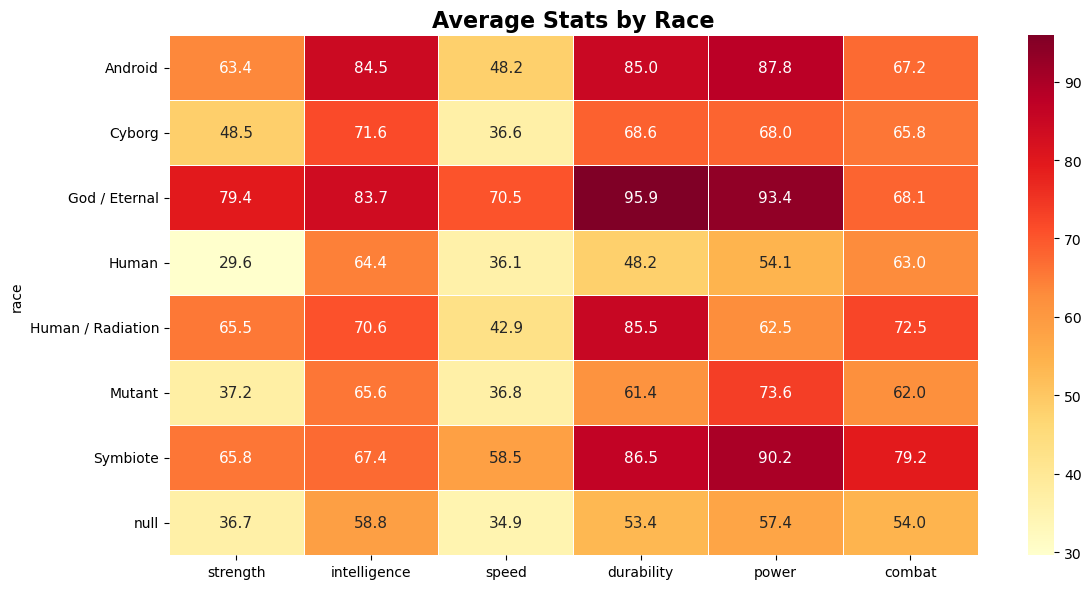

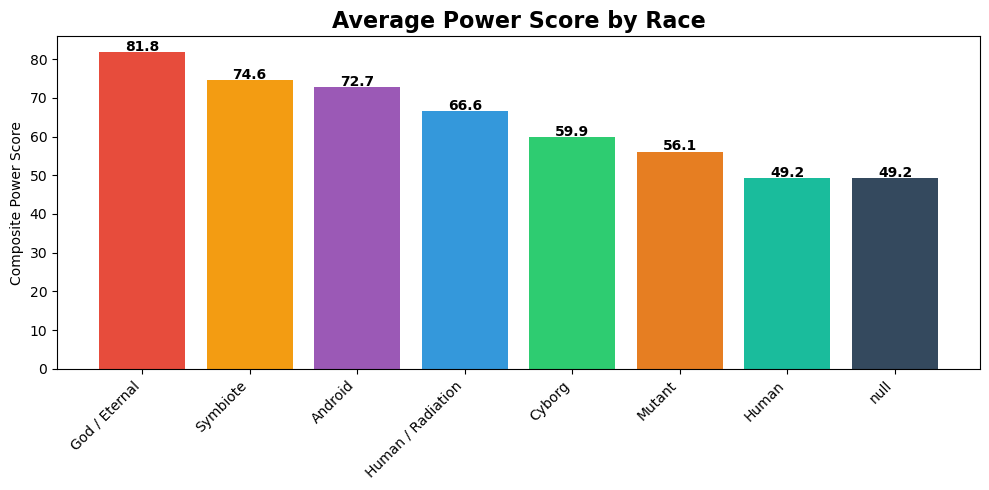

race
God / Eternal        81.8
Symbiote             74.6
Android              72.7
Human / Radiation    66.6
Cyborg               59.9
Mutant               56.1
Human                49.2
null                 49.2
Name: power_score, dtype: float64


In [14]:
# Top races by count
top_races = valid['race'].value_counts().head(8).index.tolist()
race_df = valid[valid['race'].isin(top_races)]

race_avg = race_df.groupby('race')[stats_list].mean().round(1)

# Heatmap of average stats per race
plt.figure(figsize=(12, 6))
sns.heatmap(race_avg, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Average Stats by Race', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Bar chart — composite power score per race
race_df = race_df.copy()
race_df['power_score'] = race_df[stats_list].mean(axis=1)
race_power = race_df.groupby('race')['power_score'].mean().sort_values(ascending=False).round(1)

plt.figure(figsize=(10, 5))
bars = plt.bar(race_power.index, race_power.values, 
               color=['#E74C3C', '#F39C12', '#9B59B6', '#3498DB', '#2ECC71', '#E67E22', '#1ABC9C', '#34495E'])
plt.title('Average Power Score by Race', fontsize=16, fontweight='bold')
plt.ylabel('Composite Power Score')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, race_power.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(race_power)

🏆 MOST BALANCED HEROES (low stat variance):
               name  balance_score  power_score  strength  intelligence  speed  durability  power  combat
0          Beyonder            6.5         97.3       100           100    100         100    100      84
30            Faora            9.1         91.0        95            88     75         100     98      90
7         Wolfsbane           10.3         33.2        16            38     35          42     26      42
42  Cyborg Superman           10.4         90.0        93            75     92         100    100      80
12            Quill           10.5         18.5        10            38     12          14     23      14

⚡ MOST SPECIALIZED HEROES (high stat variance):
              name  balance_score  power_score  strength  intelligence  speed  durability  power  combat
26  Solomon Grundy           43.2         56.2        93             9     13         100     92      30
8   Doctor Strange           41.4         61.0        10     

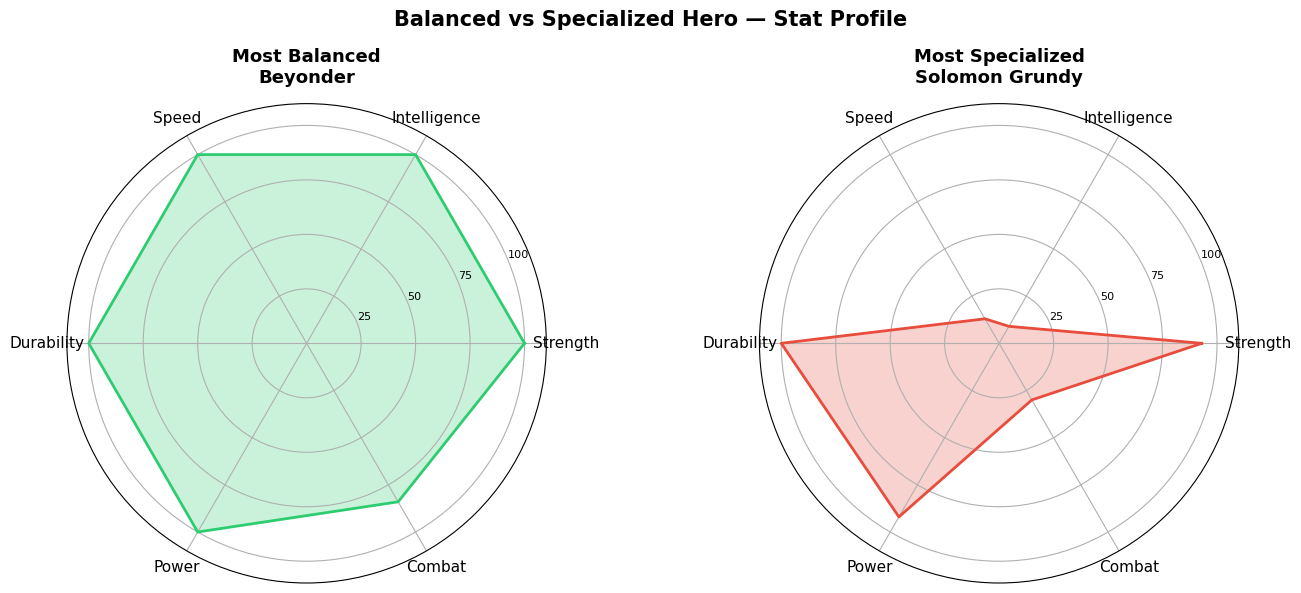

In [15]:
# Calculate balance score = how evenly distributed stats are
# Low std deviation = balanced, High std deviation = specialized
deck_df['balance_score'] = deck_df[stats_list].std(axis=1).round(1)
deck_df['power_score'] = deck_df[stats_list].mean(axis=1).round(1)

most_balanced = deck_df.nsmallest(5, 'balance_score')[['name', 'balance_score', 'power_score'] + stats_list]
most_specialized = deck_df.nlargest(5, 'balance_score')[['name', 'balance_score', 'power_score'] + stats_list]

print("🏆 MOST BALANCED HEROES (low stat variance):")
print(most_balanced.to_string())
print()
print("⚡ MOST SPECIALIZED HEROES (high stat variance):")
print(most_specialized.to_string())

# Radar chart for top balanced vs top specialized
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

def radar_chart(ax, hero_row, title, color):
    values = [hero_row[s] for s in stats_list]
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(stats_list), endpoint=False).tolist()
    angles += angles[:1]
    
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([s.capitalize() for s in stats_list], fontsize=11)
    ax.set_ylim(0, 110)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(['25', '50', '75', '100'], fontsize=8)

balanced_hero = most_balanced.iloc[0]
specialized_hero = most_specialized.iloc[0]

radar_chart(axes[0], balanced_hero, f"Most Balanced\n{balanced_hero['name']}", '#2ECC71')
radar_chart(axes[1], specialized_hero, f"Most Specialized\n{specialized_hero['name']}", '#E74C3C')

plt.suptitle('Balanced vs Specialized Hero — Stat Profile', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

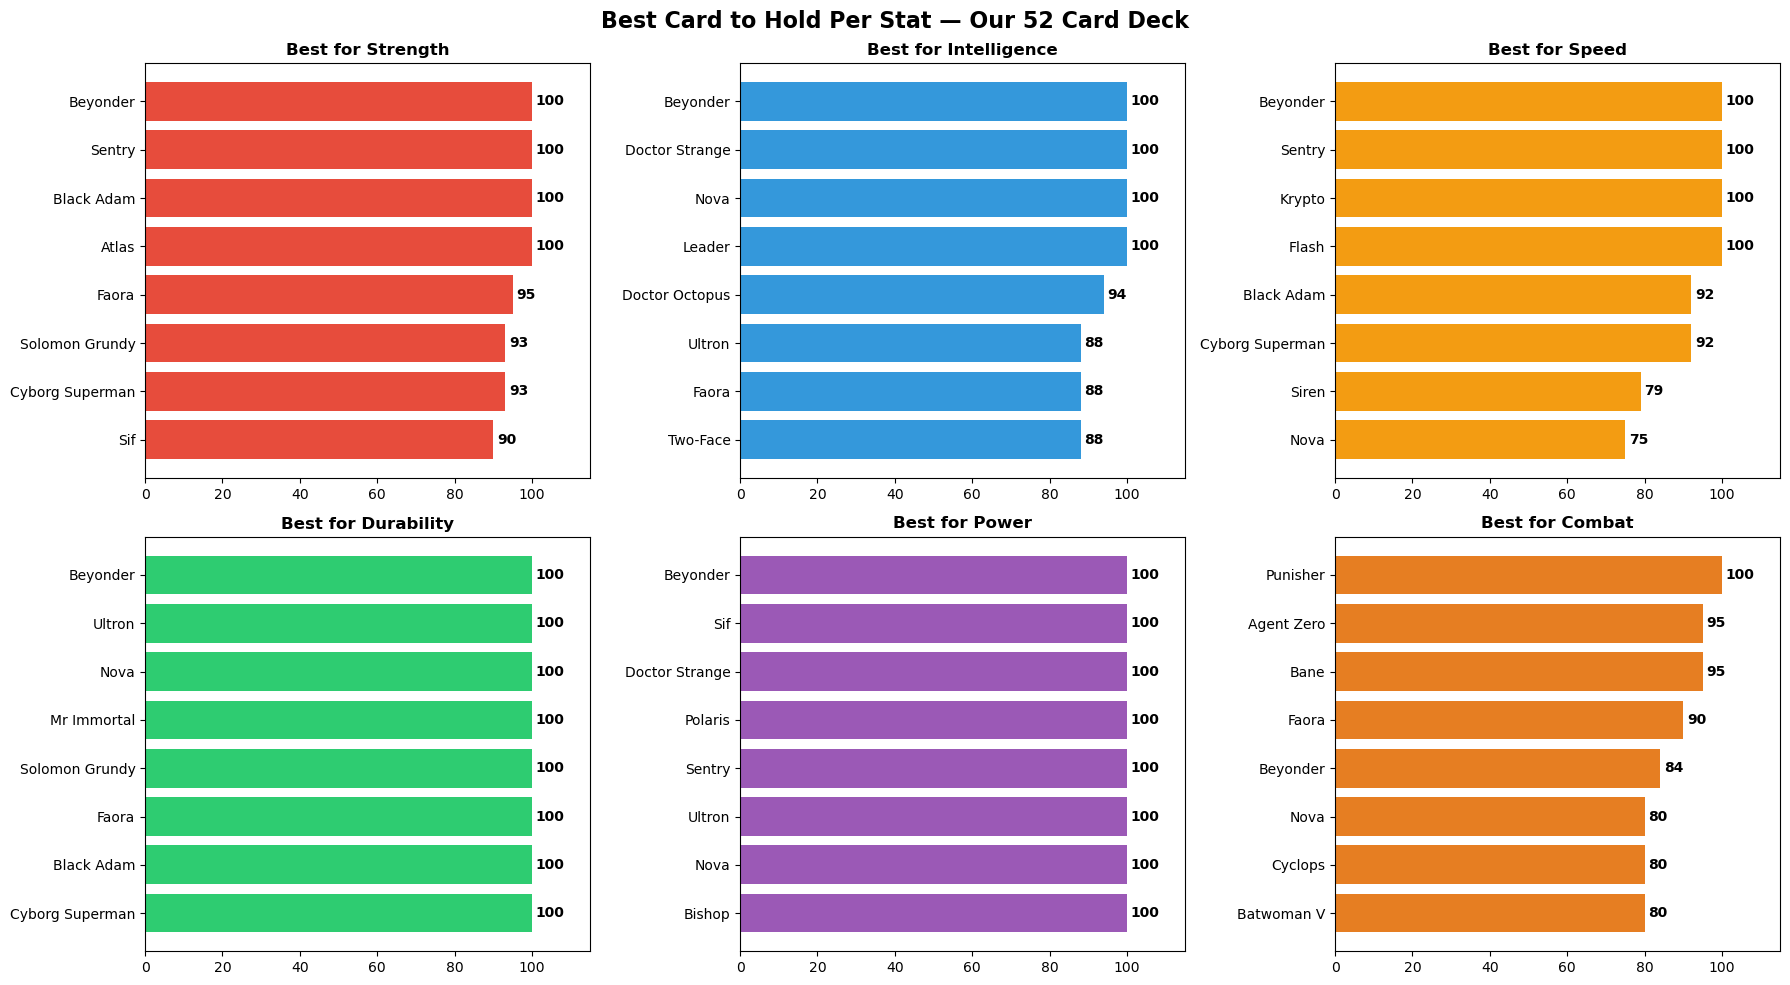

📊 BEST CARD PER STAT IN OUR DECK:
----------------------------------------
Strength        → Beyonder             (100)
Intelligence    → Beyonder             (100)
Speed           → Beyonder             (100)
Durability      → Beyonder             (100)
Power           → Beyonder             (100)
Combat          → Punisher             (100)


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Best Card to Hold Per Stat — Our 52 Card Deck', fontsize=16, fontweight='bold')

colors = ['#E74C3C', '#3498DB', '#F39C12', '#2ECC71', '#9B59B6', '#E67E22']

for ax, stat, color in zip(axes.flatten(), stats_list, colors):
    top8 = deck_df.nlargest(8, stat)[['name', stat]]
    bars = ax.barh(top8['name'], top8[stat], color=color)
    ax.set_title(f'Best for {stat.capitalize()}', fontweight='bold')
    ax.set_xlim(0, 115)
    for bar, val in zip(bars, top8[stat]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Summary table
print("📊 BEST CARD PER STAT IN OUR DECK:")
print("-" * 40)
for stat in stats_list:
    best = deck_df.loc[deck_df[stat].idxmax()]
    print(f"{stat.capitalize():15} → {best['name']:20} ({best[stat]})")